<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/Transformaciones_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA y el Teorema de Eckart-Young-Mirsky

Esta lámina explica por qué el Análisis de Componentes Principales (PCA) no es un invento arbitrario, sino la solución matemática óptima a un problema de compresión.


## 1. El Fundamento: Teorema de Eckart-Young-Mirsky (EYM)

El teorema de EYM responde a la pregunta: *Si tengo una matriz de datos $X$ y quiero simplificarla en una matriz $\hat{X}$ de menor rango ($k$), ¿cuál es la que menos información pierde?*

### La Matemática del Error
Buscamos minimizar el error usando la **Norma de Frobenius ($||\cdot||_F$)**, que es básicamente la raíz de la suma de todos los elementos de la matriz al cuadrado:

$$\min_{\text{rango}(\hat{X})=k} ||X - \hat{X}||_F$$

### La Solución: SVD Truncada
El teorema demuestra que la mejor aproximación es realizar la **Descomposición en Valores Singulares (SVD)** y quedarse solo con los $k$ componentes más importantes:

$$\hat{X} = U_k \Sigma_k V_k^T$$

* **$U_k$:** Las direcciones (vectores propios).
* **$\Sigma_k$:** La importancia de cada dirección (valores singulares).
* **$V_k^T$:** La proyección de las variables originales.




## 2. Autoencoders: PCA con Esteroides

Un **Autoencoder** es una red neuronal diseñada para comprimir datos (Encoder) y luego reconstruirlos (Decoder).

### PCA vs. Autoencoders
* **PCA (Lineal):** Solo puede encontrar "planos" o subespacios rectos. Si tus datos tienen una estructura curva, PCA los va a aplastar y perderás la esencia de la información.
* **Autoencoders (No Lineales):** Al usar funciones de activación como **ReLU**, la red puede aprender **Variedades Curvas (Manifolds)**.

> **Analogía:** Si tus datos son una hoja de papel arrugada, PCA intentará ver la sombra de la hoja en el piso. Un Autoencoder intentará aprender cómo desdoblar la hoja para entender su forma real.




## 3. ¿Cuándo usar cada uno?

| Característica | PCA | Autoencoders |
| :--- | :--- | :--- |
| **Relación** | Lineal | No Lineal |
| **Geometría** | Proyecta en planos. | Aprende curvas (Manifolds). |
| **Costo** | Barato y rápido. | Requiere entrenamiento (GPU). |
| **Interpretación** | Alta (Vectores propios). | Baja (Caja negra). |

---

### Conclusión para el laboratorio:
Usamos **PCA** cuando queremos eficiencia y sabemos que las variables se mueven juntas de forma lineal (ej. tasas de interés). Usamos **Autoencoders** cuando el fenómeno es complejo y caprichoso (ej. patrones de fraude o comportamiento de usuarios), donde una línea recta no es suficiente para capturar la realidad.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


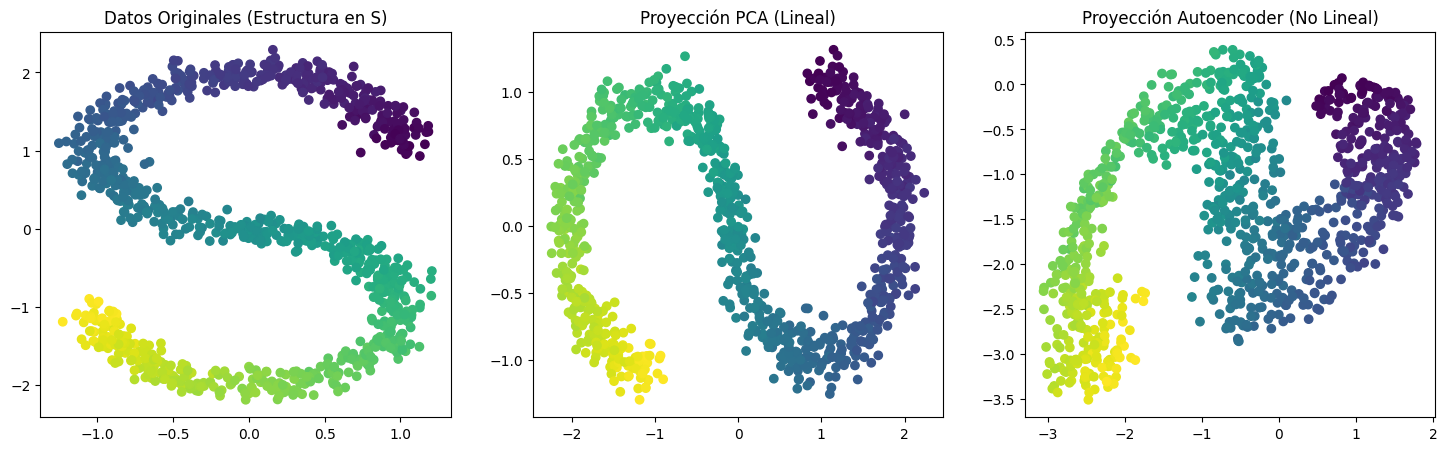

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_s_curve
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Generamos datos en 3D con una estructura curva (Manifold)
X, color = make_s_curve(n_samples=1000, noise=0.1, random_state=42)

# 2. PCA Tradicional (Lineal)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Autoencoder (No Lineal)
input_dim = Input(shape=(3,))
# Encoder
encoded = Dense(12, activation='relu')(input_dim)
bottleneck = Dense(2, activation='linear')(encoded) # Espacio de 2D
# Decoder
decoded = Dense(12, activation='relu')(bottleneck)
output_dim = Dense(3, activation='linear')(decoded)

autoencoder = Model(input_dim, output_dim)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X, X, epochs=100, batch_size=32, verbose=0)

# Extraemos la proyección del bottleneck
encoder_model = Model(input_dim, bottleneck)
X_ae = encoder_model.predict(X)

# 4. Visualización
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Original 3D (visto desde arriba para simplificar)
ax[0].scatter(X[:, 0], X[:, 2], c=color, cmap='viridis')
ax[0].set_title('Datos Originales (Estructura en S)')

# Resultado PCA
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap='viridis')
ax[1].set_title('Proyección PCA (Lineal)')

# Resultado Autoencoder
ax[2].scatter(X_ae[:, 0], X_ae[:, 1], c=color, cmap='viridis')
ax[2].set_title('Proyección Autoencoder (No Lineal)')

plt.show()

# Estandarización vs. Normalización

En Machine Learning, si tus variables tienen escalas muy distintas (ej. Edad de 0-100 vs. Sueldo de 0-200,000), el modelo le va a dar más importancia a la variable con números grandes. Escalar los datos nivela el campo de juego.



## 1. Normalización (Min-Max Scaling)

La normalización "aplasta" todos los valores para que queden estrictamente dentro de un rango, usualmente entre **0 y 1**.

### La Fórmula
$$x' = \frac{x - \text{min}(x)}{\text{max}(x) - \text{min}(x)}$$

* **Resultado:** El valor mínimo de la serie se vuelve 0 y el máximo se vuelve 1.
* **Cuándo usarla:**
    * Cuando no conoces la distribución de tus datos.
    * En algoritmos que no asumen una distribución normal (ej. K-Nearest Neighbors o Redes Neuronales).
* **El Problema:** Es **extremadamente sensible a outliers**. Si tienes un valor atípico gigante, todos los demás datos se van a ver amontonados cerca del cero.





## 2. Estandarización (Z-score Normalization)

La estandarización transforma los datos para que tengan una **media de 0** y una **desviación estándar de 1**.

### La Fórmula
$$z = \frac{x - \mu}{\sigma}$$

* **Resultado:** Centra los datos en el cero. Los valores positivos están por encima de la media y los negativos por debajo.
* **Cuándo usarla:**
    * En algoritmos que asumen datos con distribución Gaussiana (Normal).
    * Es **obligatoria** para PCA, Regresión Lineal, Regresión Logística y SVMs.
* **Ventaja:** Es mucho más robusta ante outliers que la normalización, ya que no tiene un rango fijo.





## 📊 Tabla Comparativa: ¿Cuál elegir?

| Característica | Normalización (Min-Max) | Estandarización (Z-score) |
| :--- | :---: | :---: |
| **Rango** | Fijo (0 a 1) | No tiene rango fijo. |
| **Media / Desviación** | Varía. | Media = 0, Std = 1. |
| **Outliers** | Muy sensible (los "rompe"). | Más robusta. |
| **Distribución** | No asume nada. | Ideal para distribuciones normales. |
| **Uso común** | Redes Neuronales e Imágenes. | PCA, Modelos Lineales y Clustering. |


In [4]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Datos: Sueldo y Edad
data = [[20000, 25], [45000, 30], [150000, 50], [30000, 22], [50000, 35], [25000, 28]]
df = pd.DataFrame(data, columns=['sueldo', 'edad'])

# 1. DIVIDIR (Crucial para no hacer trampa)
train, test = train_test_split(df, test_size=0.2, random_state=42)

# 2. ENTRENAR (Fit) solo con Train
std = StandardScaler()
train_std = std.fit_transform(train) # Aquí aprende la media y la desviación

# 3. GUARDAR el escalador entrenado
joblib.dump(std, 'escalador_entrenado.pkl')

# --- EN OTRO MOMENTO (PRODUCCIÓN) ---

# 4. CARGAR
scaler_cargado = joblib.load('escalador_entrenado.pkl')

# 5. TRANSFORMAR (Solo transform, NO fit)
test_scaled = scaler_cargado.transform(test)
print("Datos de prueba escalados con la memoria del entrenamiento:")
print(test_scaled)

Datos de prueba escalados con la memoria del entrenamiento:
[[-0.863474   -0.83737809]
 [-0.37006028 -0.35887632]]


In [5]:
import json
import numpy as np

# 1. Extraer las "tripas" del escalador entrenado
params = {
    "mean": std.mean_.tolist(),
    "std": np.sqrt(std.var_).tolist(), # std es la raíz de la varianza
    "columns": ['sueldo', 'edad']
}

# 2. GUARDAR en JSON
with open('escalador_pro.json', 'w') as f:
    json.dump(params, f)

# --- RECONSTRUCCIÓN MANUAL ---

# 3. CARGAR desde JSON
with open('escalador_pro.json', 'r') as f:
    config = json.load(f)

# 4. APLICAR la fórmula a mano (así se hace en producción real)
media = np.array(config['mean'])
desviacion = np.array(config['std'])

# Supongamos que llega un dato nuevo: [Sueldo 35000, Edad 28]
nuevo_dato = np.array([35000, 28])
nuevo_dato_escalado = (nuevo_dato - media) / desviacion

print(f"Resultado manual vía JSON: {nuevo_dato_escalado}")

Resultado manual vía JSON: [-0.56742577 -0.55027703]


Guardar el .pkl es como guardar los lentes graduados de tu modelo. Si en producción intentas hacer fit otra vez, es como si el modelo tratara de operarse los ojos cada vez que ve a un paciente nuevo. Se entrena una vez, se usa siempre.

#  Escalamiento Robusto y Transformaciones Pro

Cuando los datos no son perfectos (casi siempre), la Estandarización y la Normalización se quedan cortas. Aquí entran las herramientas para manejar datos reales y evitar el "Data Leakage".

---

## 1. RobustScaler (Escalado por Mediana e IQR)

Si tienes outliers extremos (ej. un sueldo de $\$$2,000,000 en una muestra de \$30,000), la media y la desviación estándar se ven arrastradas por ese valor. El **RobustScaler** ignora los extremos y se enfoca en el grueso de la población.

### La Fórmula
$$x' = \frac{x - Q_2(x)}{Q_3(x) - Q_1(x)}$$

* **Lógica:** Restas la **Mediana** ($Q_2$) y divides entre el **Rango Intercuartílico** ($Q_3 - Q_1$).
* **Ventaja:** Los outliers no afectan el escalado del resto de los datos. Es la opción más segura cuando no has limpiado la base a fondo.



---

## 2. PowerTransformer (Haciendo los datos "Normales")

Muchos modelos (como la Regresión Lineal o LDA) funcionan mucho mejor si los datos tienen una distribución de campana (Gaussiana). Si tus datos están sesgados (muchos valores bajos y pocos altos), necesitas una **Transformación de Potencia**.

* **Yeo-Johnson / Box-Cox:** Estas transformaciones estabilizan la varianza y hacen que los datos se vean "normales" a la fuerza.

### ¿Cuándo usarla?
* Cuando tus residuos no son normales.
* Cuando tienes varianza que cambia con el tiempo (Heterocedasticidad).



---

## ⚠️ El Pecado Capital: Data Leakage en el Escalado

Este es el error que reprueba a cualquier alumno. **Nunca** debes calcular los parámetros de escalado (media, min, max) usando todo el dataset.

1.  **Divide primero:** Haz tu `train_test_split`.
2.  **Fit en Train:** Calcula la media/min/max solo con los datos de entrenamiento.
3.  **Transform en ambos:** Usa esos mismos valores para escalar tanto el entrenamiento como la prueba.

> **¿Por qué?** Si usas la media de todo el dataset, tu modelo "ya sabe" el promedio del futuro (los datos de prueba) y tus resultados de validación serán una mentira.



---

## 📊 Tabla Comparativa Pro

| Escalador | Robusto a Outliers | Cambia la Distribución | Uso Recomendado |
| :--- | :---: | :---: | :--- |
| **Min-Max** | ❌ No | No | Redes Neuronales, Imágenes. |
| **Standard** | ❌ No | No | PCA, Regresiones, SVM. |
| **Robust** | ✅ Sí | No | Datos con muchos valores atípicos. |
| **Power** | ⚠️ Regular | ✅ Sí | Cuando necesitas Normalidad (Gaussian). |

---

## 🛠️ Implementación Experta (Pipeline)

La forma profesional de hacerlo es usando un `Pipeline` para evitar errores de leakage:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor

# Creamos el flujo de trabajo
pipeline = Pipeline([
    ('scaler', RobustScaler()),      # Escalamos de forma robusta
    ('model', RandomForestRegressor()) # Entrenamos
])

# El pipeline se encarga de no contaminar los datos
pipeline.fit(X_train, y_train)

#  Métodos de Encoding: De Categóricos a Numéricos

En Machine Learning, los modelos son funciones matemáticas que operan en espacios vectoriales. Como no pueden procesar "palabras", el **Encoding** transforma etiquetas de texto en representaciones numéricas que preservan la información original.



## 1. Label Encoding
Asigna un identificador entero único a cada categoría basándose, generalmente, en el orden alfabético.

* **Lógica:** $\{A, B, C\} \rightarrow \{0, 1, 2\}$
* **Uso Ideal:** Únicamente para variables **ordinales**. Aquellas donde existe una jerarquía intrínseca (ej. Nivel de estudios: Primaria < Secundaria < Grado).
* **Peligro:** Si se aplica a variables **nominales** (ej. País, Color), el modelo interpretará erróneamente que "País 2" es mayor que "País 0", introduciendo un sesgo de magnitud que no existe en la realidad.



## 2. One-Hot Encoding (OHE)
Crea una nueva columna binaria (**0** o **1**) por cada categoría única presente en la variable original.

* **Lógica:** Si tienes $N$ categorías, generas $N$ columnas. Solo una de estas columnas tendrá el valor **1** para cada registro.
* **Uso Ideal:** Variables **nominales** con **baja cardinalidad** (pocos valores únicos).
* **Desventaja:** Sufre de la **"Maldición de la Dimensionalidad"**. Si una variable tiene cientos de categorías, el dataset se vuelve extremadamente disperso (*sparse*), lo que ralentiza el entrenamiento y consume memoria excesiva.




## 3. Target Encoding (Bayesian Encoding)
Sustituye la categoría por el valor esperado de la variable objetivo ($y$) dado esa categoría.

* **Lógica:** Se calcula la media del target para cada grupo: $$\hat{x}_i = E[y | x = x_i]$$
* **Uso Ideal:** Variables con **alta cardinalidad** (ej. Códigos Postales, SKUs de productos, Colonias).
* **Riesgo Crítico:** **Data Leakage**. Si no se utiliza un factor de suavizado (*smoothing*), el modelo puede memorizar el target de entrenamiento, resultando en un sobreajuste severo. Es fundamental aplicar técnicas bayesianas para promediar la media del grupo con la media global.



## 4. Binary Encoding
Es un híbrido que combina la eficiencia de espacio con la representación categórica. Primero convierte la categoría en un entero y luego ese entero en código binario, separando cada bit en una columna distinta.

* **Lógica:** Para $N$ categorías, solo requiere $\lceil \log_2 N \rceil$ columnas. Por ejemplo, para **1,000** categorías, en lugar de 1,000 columnas (OHE), solo crea **10**.
* **Uso Ideal:** Variables con **alta cardinalidad** donde el One-Hot es inviable y se quiere evitar el riesgo de *leakage* del Target Encoding.



## 📊 Cuadro Comparativo de Decisión

| Método | Tipo de Variable | Cardinalidad | Espacio (Columnas) | Riesgo Principal |
| :--- | :--- | :--- | :---: | :--- |
| **Label** | Ordinal | Baja | No genera | Inventar orden jerárquico. |
| **One-Hot** | Nominal | Baja | Muchas ($N$) | Explosión de dimensiones. |
| **Target** | Nominal | **Alta** | No genera | Sobreajuste (Data Leakage). |
| **Binary** | Nominal | Media/Alta | Pocas ($\log_2 N$) | Menor interpretabilidad. |

---

> **Mantra para la clase:**
> "Usa **Label** si hay orden, **One-Hot** si son poquitos, y **Target** o **Binary** si el dataset se pone pesado. Pero hagas lo que hagas, ¡nunca entrenes el encoder con los datos de prueba!"

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.DataFrame({'talla': ['S', 'M', 'L', 'S', 'L']})

# Orden lógico: S < M < L
le = LabelEncoder()
df['talla_enc'] = le.fit_transform(df['talla'])

print("Label Encoding (Cuidado con el orden implícito):")
print(df)



# --- ENTRENAMIENTO ---
le = LabelEncoder()
le.fit(['S', 'M', 'L', 'XL'])

# Guardar
joblib.dump(le, 'label_encoder_tallas.pkl')

# --- PRODUCCIÓN ---
le_cargado = joblib.load('label_encoder_tallas.pkl')
# Solo transform, NUNCA fit
print(le_cargado.transform(['M', 'S']))

Label Encoding (Cuidado con el orden implícito):
  talla  talla_enc
0     S          2
1     M          1
2     L          0
3     S          2
4     L          0
[1 2]


In [8]:
import pandas as pd

df = pd.DataFrame({'color': ['Rojo', 'Azul', 'Verde', 'Rojo']})

# drop_first=True evita la colinealidad (Dummy Variable Trap)
df_ohe = pd.get_dummies(df['color'], prefix='color', drop_first=True)

print("One-Hot Encoding (Evitando la trampa de variables dummy):")
print(pd.concat([df, df_ohe], axis=1))

from sklearn.preprocessing import OneHotEncoder

# --- ENTRENAMIENTO ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
data = pd.DataFrame({'color': ['Rojo', 'Azul', 'Verde']})
ohe.fit(data)

# Guardar
joblib.dump(ohe, 'ohe_colores.pkl')

# --- PRODUCCIÓN ---
ohe_cargado = joblib.load('ohe_colores.pkl')
nuevo_dato = pd.DataFrame({'color': ['Rojo']})
print(ohe_cargado.transform(nuevo_dato))

One-Hot Encoding (Evitando la trampa de variables dummy):
   color  color_Rojo  color_Verde
0   Rojo        True        False
1   Azul       False        False
2  Verde       False         True
3   Rojo        True        False
[[0. 1. 0.]]


In [6]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [14]:
# Requiere: pip install category_encoders
from category_encoders import TargetEncoder
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'ciudad': ['CDMX', 'CDMX', 'GDL', 'GDL', 'MTY'],
    'target': [1, 0, 1, 1, 0] # Siniestro (1) o No (0)
})

# El suavizado (smoothing) es lo que lo hace "Bayesiano"
te = TargetEncoder(smoothing=10)
df['ciudad_enc'] = te.fit_transform(df['ciudad'], df['target'])

print("Target Encoding (Basado en la probabilidad del evento):")
print(df)




# 1. Datos de ejemplo
df = pd.DataFrame({
    'ciudad': ['CDMX', 'GDL', 'MTY', 'CDMX'],
    'target': [1, 0, 1, 1]
})

# 2. Entrenar (FIT)
te = TargetEncoder(cols=['ciudad'])
te.fit(df['ciudad'], df['target'])

# --- EXTRACCIÓN A PRUEBA DE BALAS ---
master_mapping = {}

# Si te.mapping es una lista (caso común)
if isinstance(te.mapping, list):
    for entry in te.mapping:
        # Si por alguna razón la lista trae strings, esto lo evita
        if isinstance(entry, dict):
            col_name = entry.get('col')
            mapping_series = entry.get('mapping')
            master_mapping[col_name] = mapping_series.to_dict()

# Si te.mapping es un diccionario (el caso de tu error)
elif isinstance(te.mapping, dict):
    for col_name, mapping_series in te.mapping.items():
        master_mapping[col_name] = mapping_series.to_dict()

# 3. Guardar en JSON
# Usamos un encoder para que maneje tipos de numpy si es necesario
def default_converter(obj):
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

with open('encodings_final.json', 'w') as f:
    json.dump(master_mapping, f, indent=4, default=default_converter)

print("✅ guardado 'encodings_final.json'")

Target Encoding (Basado en la probabilidad del evento):
  ciudad  target  ciudad_enc
0   CDMX       1    0.585815
1   CDMX       0    0.585815
2    GDL       1    0.656740
3    GDL       1    0.656740
4    MTY       0    0.521935
✅ guardado 'encodings_final.json'


In [15]:
import joblib

# GUARDAR: Guarda el objeto te completito
joblib.dump(te, 'target_encoder_full.pkl')

# CARGAR: En tu script de producción
te_cargado = joblib.load('target_encoder_full.pkl')

# USAR: Directo, sin loops, sin JSONs, sin broncas
df_nuevo = pd.DataFrame({'ciudad': ['CDMX', 'GDL', 'Cancun']})
df_ready = te_cargado.transform(df_nuevo)

print("✅ Usando el .pkl cargado:")
print(df_ready)

✅ Usando el .pkl cargado:
     ciudad
0  0.785463
1  0.652419
2  0.750000


In [10]:
from category_encoders import BinaryEncoder
import pandas as pd

df = pd.DataFrame({'modelo_auto': ['Tsuru', 'Jetta', 'Lambo', 'Mustang', 'Tsuru', 'Lambo']})

be = BinaryEncoder()
df_bin = be.fit_transform(df['modelo_auto'])

print("Binary Encoding (Eficiencia en alta cardinalidad):")
print(pd.concat([df, df_bin], axis=1))

# --- ENTRENAMIENTO ---
be = BinaryEncoder()
df = pd.DataFrame({'modelo': ['Tsuru', 'Jetta', 'Lambo']})
be.fit(df)

# Guardar
joblib.dump(be, 'binary_enc_modelos.pkl')

# --- PRODUCCIÓN ---
be_cargado = joblib.load('binary_enc_modelos.pkl')
print(be_cargado.transform(pd.DataFrame({'modelo': ['Jetta']})))

Binary Encoding (Eficiencia en alta cardinalidad):
  modelo_auto  modelo_auto_0  modelo_auto_1  modelo_auto_2
0       Tsuru              0              0              1
1       Jetta              0              1              0
2       Lambo              0              1              1
3     Mustang              1              0              0
4       Tsuru              0              0              1
5       Lambo              0              1              1
   modelo_0  modelo_1
0         1         0


# Manejo de Outliers (Valores Atípicos)

Un outlier es una observación que se desvía tanto de las demás que despierta sospechas de que fue generada por un mecanismo diferente. Ignorarlos puede sesgar la media y arruinar el escalado de tus datos.

---

## 1. Método Z-Score (Desviación Estándar)
Este método se basa en la distancia de un punto respecto a la media en términos de desviaciones estándar.

* **Lógica:** Se asume que los datos siguen una **Distribución Normal**.
* **Criterio:** Cualquier punto con un Z-Score absoluto mayor a 3 (o 2.5 en casos estrictos) se considera atípico.
* **Fórmula:** $$Z = \frac{x - \mu}{\sigma}$$



* **Limitación:** Es muy sensible a los mismos outliers, ya que la media ($\mu$) y la desviación estándar ($\sigma$) se ven arrastradas por los valores extremos.



## 2. Método de Tukey (Rango Intercuartílico - IQR)
Es un método robusto que no asume una distribución normal y utiliza los cuartiles para definir los límites.

* **Lógica:** Se calcula el **IQR** como la diferencia entre el tercer cuartil ($Q3$) y el primer cuartil ($Q1$).
* **Criterio (Cercas de Tukey):**
    * **Límite Inferior:** $Q1 - 1.5 \times IQR$
    * **Límite Superior:** $Q3 + 1.5 \times IQR$



* **Ventaja:** Al usar la mediana y los cuartiles, es mucho más resistente a los valores extremos que el Z-Score. Es el estándar para generar los "bigotes" en un Boxplot.

---

## 📊 Comparativa: ¿Cuál elegir?

| Característica | Z-Score | Tukey (IQR) |
| :--- | :--- | :--- |
| **Distribución** | Requiere que sea Normal (Gaussiana). | No requiere distribución específica. |
| **Robustez** | Baja (sensible a extremos). | Alta (basado en estadísticas de orden). |
| **Uso común** | Control de procesos y manufactura. | Análisis exploratorio y limpieza general. |
| **Sensibilidad** | Detecta extremos globales. | Excelente para detectar sesgos en la muestra. |

---

## 🛠️ ¿Qué hacer con ellos?

Una vez detectados, tienes tres caminos profesionales:

1. **Recorte (Trimming):** Eliminar las filas que contienen los outliers. Úsalo solo si estás seguro de que son errores de captura.
2. **Imputación:** Reemplazar el valor atípico por la mediana o el valor del límite (Capping/Winsorizing).
3. **Transformación:** Aplicar transformaciones logarítmicas o de potencia para reducir el impacto de la cola larga.

> **Mantra de limpieza:** > "Un outlier puede ser un error de sistema o el evento más importante de tu modelo (como un fraude). Antes de borrarlo, entiende de dónde viene."

In [16]:

# --- ENTRENAMIENTO ---
data = {'valor': [10, 12, 11, 13, 12, 11, 10, 50, 12, 11]} # El 50 es outlier
df_train = pd.DataFrame(data)

mu = df_train['valor'].mean()
sigma = df_train['valor'].std()

# Guardamos los parámetros de "normalidad"
z_params = {'mean': mu, 'std': sigma, 'threshold': 3}
joblib.dump(z_params, 'zscore_thresholds.pkl')

# --- PRODUCCIÓN ---
params = joblib.load('zscore_thresholds.pkl')
df_new = pd.DataFrame({'valor': [11, 100, 12]}) # El 100 es outlier nuevo

# Calculamos Z-Score con la memoria del entrenamiento
z_scores = (df_new['valor'] - params['mean']) / params['std']
df_new['is_outlier'] = np.abs(z_scores) > params['threshold']

print("Detección Z-Score en Producción:")
print(df_new)

Detección Z-Score en Producción:
   valor  is_outlier
0     11       False
1    100        True
2     12       False


In [17]:

# --- ENTRENAMIENTO ---
df_train = pd.DataFrame({'ingresos': [20, 22, 25, 21, 23, 24, 150, 18, 20]})

q1 = df_train['ingresos'].quantile(0.25)
q3 = df_train['ingresos'].quantile(0.75)
iqr = q3 - q1

# Definimos los límites
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

# Guardamos los límites "aprendidos"
iqr_limits = {'low': limite_inf, 'high': limite_sup}
joblib.dump(iqr_limits, 'tukey_limits.pkl')

# --- PRODUCCIÓN (Capping / Winsorizing) ---
limits = joblib.load('tukey_limits.pkl')
df_prod = pd.DataFrame({'ingresos': [22, 500, 10]}) # 500 es outlier, 10 está abajo

# Aplicamos el "Capping": si se pasa del límite, lo sentamos en el límite
df_prod['ingresos_clean'] = df_prod['ingresos'].clip(lower=limits['low'], upper=limits['high'])

print("Limpieza Tukey (Capping) en Producción:")
print(df_prod)

Limpieza Tukey (Capping) en Producción:
   ingresos  ingresos_clean
0        22              22
1       500              30
2        10              14


#  Manejo de Valores Nulos (Missing Data)

Los valores nulos son huecos en la información que pueden hacer que tus modelos truenen o entreguen resultados sesgados. No todos los nulos se tratan igual; la estrategia depende de la naturaleza del dato.

---

## 1. Eliminación (Listwise Deletion)
Consiste en borrar las filas o columnas que contienen nulos.

* **¿Cuándo usarlo?** Solo si la cantidad de nulos es mínima (menos del 5%) y no hay un patrón detrás de su ausencia.
* **Peligro:** Puedes perder información valiosa y reducir drásticamente el tamaño de tu muestra.



## 2. Imputación Simple (Univariada)
Rellena los huecos usando estadísticas básicas de la misma columna.

* **Media ($\mu$):** Úsala para datos numéricos con distribución simétrica (sin muchos outliers).
* **Mediana ($Q_2$):** Es la mejor opción para datos numéricos con **outliers** o distribuciones sesgadas.
* **Moda:** La opción obligatoria para variables **categóricas** (el valor que más se repite).
* **Valor Constante:** Rellenar con un valor específico como `"Desconocido"` o `0`.

[Image of mean vs median imputation comparison]


## 3. Imputación Avanzada: KNN Imputer
En lugar de usar el promedio de toda la columna, el **KNN Imputer** busca los $k$ registros más parecidos (vecinos) y usa sus valores para promediar el dato faltante.

* **Lógica:** Si un cliente tiene sueldo nulo pero su edad y nivel educativo coinciden con otros tres clientes, usamos el sueldo promedio de esos tres.
* **Ventaja:** Preserva mucho mejor las relaciones entre variables que la imputación simple.

[Image of KNN imputer mechanism for missing values]


## 📊 Comparativa de Estrategias

| Método | Tipo de Dato | Ventaja | Desventaja |
| :--- | :--- | :--- | :--- |
| **Media/Mediana** | Numérico | Rápido y sencillo. | Reduce la varianza y ignora correlaciones. |
| **Moda** | Categórico | Fácil de implementar. | Puede sesgar la clase mayoritaria. |
| **KNN Imputer** | Ambos | Muy preciso y realista. | Computacionalmente caro (lento en bases grandes). |
| **Iterative Imputer** | Numérico | Considera todas las variables. | Puede sobreajustar si no se cuida. |



## ⚠️ El Error que no te perdonan: Data Leakage

Al igual que con el escalado, la **Imputación** debe seguir un orden estricto:

1.  **Calcula (Fit):** Obtén la media/mediana/moda **solo con los datos de entrenamiento**.
2.  **Aplica (Transform):** Rellena los nulos tanto en entrenamiento como en prueba usando esos valores.

> **¿Por qué?** Si usas la media de todo el dataset para rellenar los nulos de entrenamiento, estás "filtrando" información del futuro (los datos de prueba) hacia tu modelo.



### Mantra de Limpieza:
> "Un valor nulo no es un error, es un dato en sí mismo. A veces, que el dato no esté es la información más importante que el modelo necesita capturar."

In [18]:

from sklearn.impute import SimpleImputer

# --- ENTRENAMIENTO ---
data = {'edad': [25, 30, np.nan, 35, 40, 100], 'sucursal': ['A', 'A', 'B', np.nan, 'A', 'B']}
df_train = pd.DataFrame(data)

# 1. Definimos imputadores (Numérico y Categórico)
imputer_num = SimpleImputer(strategy='median') # Mediana por el outlier (100)
imputer_cat = SimpleImputer(strategy='most_frequent') # Moda para categorías

# 2. Entrenamos (Fit)
imputer_num.fit(df_train[['edad']])
imputer_cat.fit(df_train[['sucursal']])

# 3. Guardamos la "memoria"
joblib.dump(imputer_num, 'imputer_edad.pkl')
joblib.dump(imputer_cat, 'imputer_sucursal.pkl')

print("✅ Imputadores simples guardados.")

✅ Imputadores simples guardados.


In [22]:

from sklearn.impute import KNNImputer

# --- ENTRENAMIENTO ---
# Necesitamos varias columnas numéricas para que KNN "encuentre" vecinos
data_knn = {
    'ingresos': [50, 60, 55, 80, np.nan],
    'edad': [25, 30, 28, 45, 40],
    'score': [700, 710, 690, 800, 750]
}
df_knn = pd.DataFrame(data_knn)

# Definimos el imputador con 2 vecinos
knn_imputer = KNNImputer(n_neighbors=2)

# Entrenamos
knn_imputer.fit(df_knn)

# Guardamos el objeto completo (pesa más que el simple)
joblib.dump(knn_imputer, 'knn_imputer_model.pkl')

print("✅ KNN Imputer guardado.")


# 1. Cargamos la memoria
imp_edad = joblib.load('imputer_edad.pkl')
imp_sucursal = joblib.load('imputer_sucursal.pkl')

# 2. Llega un dato nuevo con nulos
nuevo_cliente = pd.DataFrame({'edad': [np.nan], 'sucursal': [np.nan]})

# 3. Aplicamos (Transform)
nuevo_cliente['edad'] = imp_edad.transform(nuevo_cliente[['edad']]).ravel()
nuevo_cliente['sucursal'] = imp_sucursal.transform(nuevo_cliente[['sucursal']]).ravel()

print("✅ Ahora sí, cliente listo:")
print(nuevo_cliente)

✅ KNN Imputer guardado.
✅ Ahora sí, cliente listo:
   edad sucursal
0  35.0        A


## Tabla Maestra: Flujo Lógico de Preprocesamiento

Seguir este orden es vital para asegurar la integridad de los datos y evitar sesgos en el modelo. No puedes escalar lo que no existe (nulos) ni codificar lo que no es estable (outliers).

| Orden | Paso Técnico | ¿Por qué en este lugar? | Riesgo de Alterar el Orden |
| :---: | :--- | :--- | :--- |
| **1** | **Manejo de Nulos** | Es la base. No puedes calcular medias, desviaciones o distancias si faltan datos. | Los algoritmos de encoding y escalado truenan con valores `NaN`. |
| **2** | **Tratamiento de Outliers** | Los valores extremos arrastran la media y la desviación estándar. | Si escalas antes de limpiar outliers, tu rango $[0, 1]$ quedará "aplastado" por el valor extremo. |
| **3** | **Encoding (Categorías)** | Transforma texto a números. Los escaladores necesitan que todo sea numérico para funcionar. | No puedes aplicar fórmulas matemáticas ($z = \frac{x - \mu}{\sigma}$) a un string como "Rojo". |
| **4** | **Escalado / Normalización** | Es el ajuste final. Nivela el campo de juego para que todas las variables tengan el mismo peso. | Si codificas después de escalar, tus variables nuevas (0/1) no estarán en la misma escala que las numéricas. |




## ⚠️ Las 3 Reglas de Oro para Producción

1. **La Memoria se guarda en el Fit:** El entrenamiento es el único momento donde se calculan medias, modas o límites. Se guardan en un `.pkl` o `.json`.
2. **Transform sin Fit en Test/Producción:** En el set de prueba o en el servidor, solo usas `.transform()`. Nunca vuelvas a calcular los parámetros con datos nuevos.
3. **El Pipeline es un Contrato:** Si en el entrenamiento el orden fue *Nulos -> Encoding -> Escalado*, en producción el código debe seguir EXACTAMENTE esa secuencia.



### Ejemplo de "Cascada" Lógica:
> Imagina que tienes una columna de **Sueldo** con nulos y un outlier de un millón:
> 1. Primero **rellenas el nulo** con la mediana (ej. 30k).
> 2. Luego **"capas" el millón** para que no joda la estadística (lo bajas a 80k).
> 3. Finalmente **escalas** (StandardScaler) para que esos valores queden centrados en 0.
> **Si lo haces al revés, el nulo te rompe el cálculo y el outlier te manda el promedio al cielo.**

# Implicaciones de escalamiento:

##Condicionamiento del Hessiano

¿Por qué escalar no es solo un capricho? La respuesta está en la **geometría de la función de costo** y cómo el optimizador la recorre.



## 1. La Curvatura y el Hessiano ($H$)
La matriz **Hessiana** contiene las segundas derivadas parciales de la función de costo $J(\theta)$. Básicamente, nos dice qué tan "curva" es la superficie de error en cada dirección.

$$H_{ij} = \frac{\partial^2 J}{\partial \theta_i \partial \theta_j}$$

## 2. El Número de Condición ($\kappa$)
El éxito del Descenso de Gradiente depende del **Número de Condición** de esta matriz, que es el radio entre el valor propio (*eigenvalue*) más grande y el más pequeño:

$$\kappa(H) = \frac{|\lambda_{max}|}{|\lambda_{min}|}$$

* **Si $\kappa \approx 1$:** La superficie es un círculo perfecto. El gradiente apunta directo al mínimo. **Convergencia inmediata.**
* **Si $\kappa \gg 1$:** La superficie es una elipse muy alargada (un "balón de fútbol americano"). El gradiente oscila violentamente de lado a lado y avanza lentísimo hacia el centro.





## 🛠️ Simulación del Hessiano en Python

Con este código puedes demostrar cómo el escalado "redondea" la función de costo, bajando el número de condición de miles a casi uno.



In [23]:
import numpy as np

# Caso 1: Variables NO escaladas
# Supongamos que X1 tiene mucha más varianza que X2
# Función de costo: J = 1000*x1^2 + 1*x2^2
hessiano_no_escalado = np.array([[2000, 0],
                                 [0, 2]])

eigenvalues_no = np.linalg.eigvals(hessiano_no_escalado)
kappa_no = np.max(eigenvalues_no) / np.min(eigenvalues_no)

print(f"--- SIN ESCALAR ---")
print(f"Eigenvalues: {eigenvalues_no}")
print(f"Número de Condición κ: {kappa_no}") # Muy alto -> Ineficiente

# Caso 2: Variables ESCALADAS
# Al estandarizar, las curvaturas se igualan
# Función de costo: J = 1*x1^2 + 1*x2^2
hessiano_escalado = np.array([[2, 0],
                              [0, 2]])

eigenvalues_si = np.linalg.eigvals(hessiano_escalado)
kappa_si = np.max(eigenvalues_si) / np.min(eigenvalues_si)

print(f"\n--- ESCALADO ---")
print(f"Eigenvalues: {eigenvalues_si}")
print(f"Número de Condición κ: {kappa_si}") # Cercano a 1 -> Óptimo

--- SIN ESCALAR ---
Eigenvalues: [2000.    2.]
Número de Condición κ: 1000.0

--- ESCALADO ---
Eigenvalues: [2. 2.]
Número de Condición κ: 1.0


## Power Transforms: Box-Cox, Yeo-Johnson y el Jacobiano

En estadística aplicada (especialmente en seguros y finanzas), a veces los datos son tan sesgados que los modelos lineales fallan. Las transformaciones de potencia buscan estabilizar la varianza y normalizar los residuos.



## 1. ¿Por qué transformar?
Para cumplir con los supuestos de los modelos de regresión:
* **Homocedasticidad:** Varianza constante de los errores.
* **Normalidad:** Residuos que sigan una campana de Gauss.

## 2. Box-Cox vs. Yeo-Johnson

| Técnica | Requisito de Datos | Aplicación Típica |
| :--- | :--- | :--- |
| **Box-Cox** | $y > 0$ (Solo positivos). | Montos de siniestros, precios de activos. |
| **Yeo-Johnson** | $y \in \mathbb{R}$ (Soporta negativos y ceros). | Siniestros netos (siniestros menos salvamentos/recuperaciones). |



## 3. El Rigor: La Verosimilitud Perfilada y el Jacobiano

Para encontrar el $\lambda$ (el parámetro de potencia) óptimo, maximizamos la función de log-verosimilitud ($\ln L$).

**El Problema:** Al cambiar $\lambda$, cambia la escala de los datos transformados. No podemos comparar verosimilitudes directamente si la "unidad de medida" cambia.

**La Solución:** Introducir el **Jacobiano ($J$)** de la transformación. El Jacobiano ajusta la verosimilitud por el cambio de volumen/escala, permitiendo una comparación justa entre distintos valores de $\lambda$:

$$\ln L(\lambda) \propto -\frac{n}{2}\ln(\hat{\sigma}^2_\lambda) + (\lambda - 1)\sum \ln(y_i)$$

> **Nota :** El término $(\lambda - 1)\sum \ln(y_i)$ es el logaritmo del determinante del Jacobiano. Sin este término, estarías eligiendo un $\lambda$ que simplemente reduce la escala de los datos, no uno que realmente los normaliza.

Vamos a simular datos de "Siniestros Netos" (que pueden ser negativos por recuperaciones) y veremos cómo Yeo-Johnson los endereza.



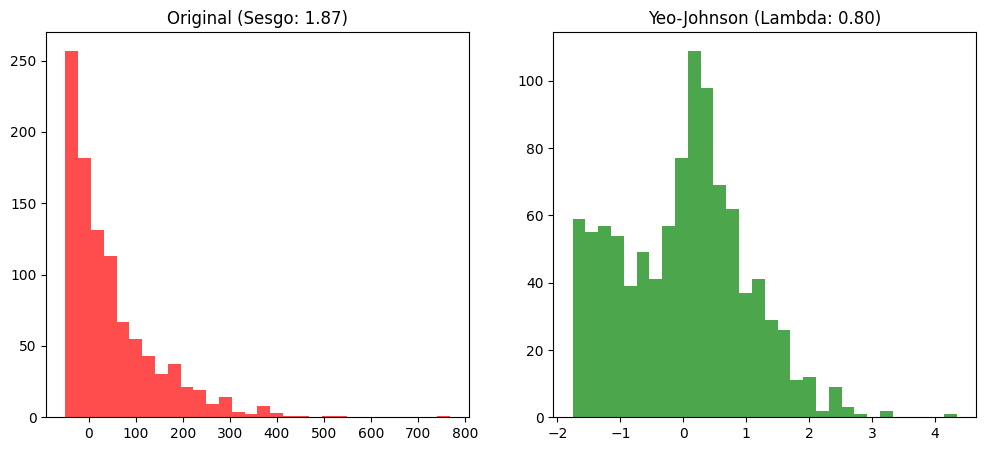

El lambda óptimo encontrado por MLE es: 0.7987


In [24]:
from sklearn.preprocessing import PowerTransformer

# 1. Simular datos muy sesgados con valores negativos (Siniestros Netos)
np.random.seed(42)
datos = np.random.exponential(scale=100, size=1000)
datos = datos - 50 # Desplazamos para tener negativos

# 2. Aplicar Yeo-Johnson
# PowerTransformer usa MLE (Maximum Likelihood Estimation) con el Jacobiano bajo el capó
pt = PowerTransformer(method='yeo-johnson')
datos_trans = pt.fit_transform(datos.reshape(-1, 1))

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(datos, bins=30, color='red', alpha=0.7)
ax1.set_title(f"Original (Sesgo: {pd.Series(datos).skew():.2f})")

ax2.hist(datos_trans, bins=30, color='green', alpha=0.7)
ax2.set_title(f"Yeo-Johnson (Lambda: {pt.lambdas_[0]:.2f})")

plt.show()

print(f"El lambda óptimo encontrado por MLE es: {pt.lambdas_[0]:.4f}")

##  Box-Cox y el Rigor del Jacobiano

A diferencia de Yeo-Johnson, la transformación **Box-Cox** es la "vieja escuela" de la estadística: extremadamente potente pero exigente. Solo acepta datos estrictamente positivos ($y > 0$).


## 1. La Transformación de Box-Cox
Para un valor de $\lambda$, la transformación se define como:

$$y^{(\lambda)} = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(y) & \text{si } \lambda = 0 \end{cases}$$

## 2. El Problema de la Comparación
Si pruebas $\lambda = 2$, tus datos podrían pasar de estar entre 1 y 10 a estar entre 1 y 100. Si pruebas $\lambda = 0.5$, quedarían entre 1 y 3.

**¿Cómo saber cuál es mejor si las escalas son tan diferentes?** No puedes usar la varianza simple para comparar. Aquí entra el **Jacobiano ($J$)**.

## 3. La Verosimilitud con Ajuste de Volumen
Para encontrar el $\lambda$ óptimo, buscamos maximizar la Log-Verosimilitud Perfilada. El término del Jacobiano compensa el cambio de escala:

$$\ln L(\lambda) = -\frac{n}{2}\ln(\hat{\sigma}^2_\lambda) + \underbrace{(\lambda - 1)\sum_{i=1}^n \ln(y_i)}_{\text{Log-Determinante del Jacobiano}}$$

* **Sin el Jacobiano:** El algoritmo elegiría el $\lambda$ que más "comprimiera" los datos (menor varianza artificial), no el que mejor los normalizara.
* **Con el Jacobiano:** El algoritmo elige el $\lambda$ que realmente hace que los datos se parezcan a una distribución Normal, sin importar la escala final.



## Ejemplo del Efecto del Jacobiano

En este ejemplo, vamos a calcular la verosimilitud "a mano" para que veas cómo el término del Jacobiano corrige la decisión del modelo.



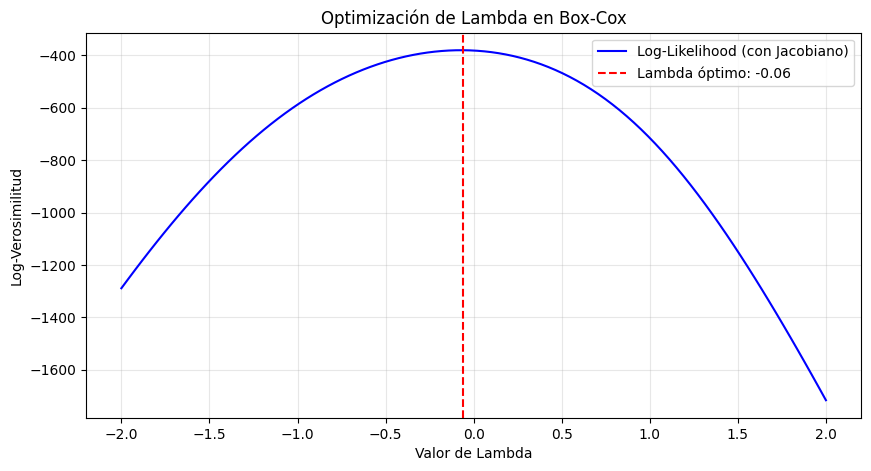

El lambda que mejor normaliza los datos es: -0.0606


In [26]:
import scipy.stats as stats


# 1. Generar datos positivos muy sesgados (Log-Normal)
np.random.seed(42)
y = np.random.lognormal(mean=1, sigma=0.8, size=500)

# 2. Función para calcular la Log-Verosimilitud Perfilada
def log_likelihood_boxcox(lmbda, data):
    n = len(data)
    # Aplicar transformación Box-Cox
    y_trans = stats.boxcox(data, lmbda=lmbda)
    # Varianza de los datos transformados
    var_lmbda = np.var(y_trans)

    # Término 1: Ajuste por varianza
    term1 = -n / 2 * np.log(var_lmbda)
    # Término 2: EL JACOBIANO (La corrección de escala)
    jacobian_log_det = (lmbda - 1) * np.sum(np.log(data))

    return term1 + jacobian_log_det

# 3. Probar diferentes valores de Lambda
lambdas = np.linspace(-2, 2, 100)
likelihoods = [log_likelihood_boxcox(l, y) for l in lambdas]

# 4. Encontrar el óptimo
lmbda_opt = lambdas[np.argmax(likelihoods)]

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(lambdas, likelihoods, label='Log-Likelihood (con Jacobiano)', color='blue')
plt.axvline(lmbda_opt, color='red', linestyle='--', label=f'Lambda óptimo: {lmbda_opt:.2f}')
plt.title("Optimización de Lambda en Box-Cox")
plt.xlabel("Valor de Lambda")
plt.ylabel("Log-Verosimilitud")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"El lambda que mejor normaliza los datos es: {lmbda_opt:.4f}")



In [31]:

# --- MÉTODO A: Scipy (Manual/Exploratorio) ---
# stats.boxcox te da el lambda y los datos transformados
xt, lmbda_opt = stats.boxcox(y)
z = xt

print(f"Lambda óptimo encontrado: {lmbda_opt:.4f}")



Lambda óptimo encontrado: -0.0709


El Jacobiano es el 'impuesto' que pagamos por cambiar la escala de los datos. Si no lo sumas a la verosimilitud, tu optimización es una mentira: estarías premiando a las transformaciones que hacen los números chiquitos en lugar de a las que los hacen normales. Scipy y Sklearn lo hacen por ti, pero un experto sabe que ahí es donde está el rigor matemático.

In [27]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

# 1. Generar datos "sucios" (Log-Normal: muy sesgados y positivos)
np.random.seed(42)
data = np.random.lognormal(mean=2, sigma=1.2, size=1000).reshape(-1, 1)
df = pd.DataFrame(data, columns=['monto_siniestro'])

# Dividimos en Train y Test (Regla de oro: El lambda se aprende solo en Train)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# --- FASE DE ENTRENAMIENTO ---

# 2. Inicializar PowerTransformer
# standardize=True aplica un StandardScaler automático después de Box-Cox
pt = PowerTransformer(method='box-cox', standardize=True)

# 3. FIT & TRANSFORM (Aquí se calcula el Jacobiano y se halla el Lambda)
df_train['monto_trans'] = pt.fit_transform(df_train[['monto_siniestro']])

# 4. GUARDAR EL OBJETO (La "memoria" del lambda)
joblib.dump(pt, 'boxcox_transformer.pkl')

print(f"✅ Entrenamiento listo. Lambda óptimo: {pt.lambdas_[0]:.4f}")

# --- FASE DE PRODUCCIÓN (Inferencia) ---

# 5. CARGAR EL TRANSFORMADOR
pt_cargado = joblib.load('boxcox_transformer.pkl')

# 6. SOLO TRANSFORM (Llegan datos nuevos, usamos el lambda que ya conocemos)
df_test['monto_trans'] = pt_cargado.transform(df_test[['monto_siniestro']])

print("✅ Datos de prueba transformados con éxito.")

✅ Entrenamiento listo. Lambda óptimo: -0.0338
✅ Datos de prueba transformados con éxito.


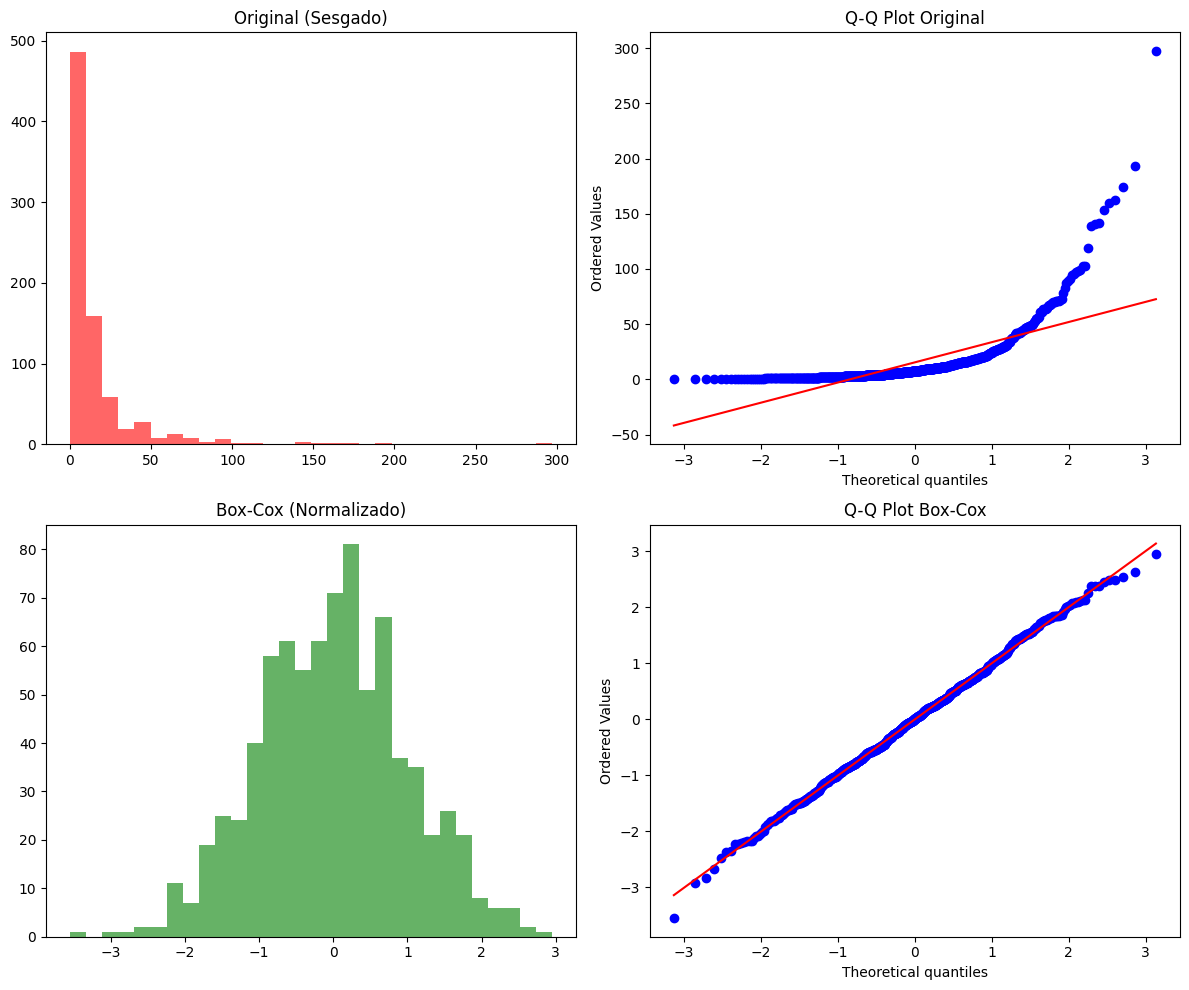

In [28]:
def plot_normality(data_original, data_trans):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Original
    axes[0,0].hist(data_original, bins=30, color='red', alpha=0.6)
    axes[0,0].set_title("Original (Sesgado)")
    stats.probplot(data_original.flatten(), dist="norm", plot=axes[0,1])
    axes[0,1].set_title("Q-Q Plot Original")

    # Transformado
    axes[1,0].hist(data_trans, bins=30, color='green', alpha=0.6)
    axes[1,0].set_title("Box-Cox (Normalizado)")
    stats.probplot(data_trans.flatten(), dist="norm", plot=axes[1,1])
    axes[1,1].set_title("Q-Q Plot Box-Cox")

    plt.tight_layout()
    plt.show()

# Usamos los datos que ya procesamos
plot_normality(df_train['monto_siniestro'].values, df_train['monto_trans'].values)

# Binning, WoE e Information Value (IV)

En modelos de riesgo, la relación entre una variable (como la edad) y el target (default o siniestro) rara vez es lineal. El **Binning** y el **WoE** son las herramientas estándar para "domar" estas variables.



## 1. Binning (Discretización)
Consiste en agrupar una variable continua en "cubetas" o intervalos.
* **Ancho Fijo:** Intervalos de igual tamaño (ej. de 10 en 10 años).
* **Frecuencia Fija (Cuantiles):** Intervalos que contienen el mismo número de registros.
* **Uso Típico:** La **Edad del Conductor**. El riesgo suele tener forma de "U": es alto en jóvenes (falta de experiencia) y en ancianos (pérdida de reflejos). El binning captura esta no-linealidad.





## 2. Weight of Evidence (WoE)
El WoE mide la fuerza de una categoría para separar el "Bien" (Target=0) del "Mal" (Target=1).

**Fórmula:**
$$WoE_j = \ln\left(\frac{P(X=x_j | Y=1)}{P(X=x_j | Y=0)}\right)$$

* **¿Por qué usarlo?** Porque linealiza la relación con los log-odds del target. Al sustituir el valor original por su WoE, una Regresión Logística puede modelar relaciones complejas de forma lineal.
* **Interpretación:** Un WoE negativo indica que la categoría tiene más "Buenos" que el promedio; un WoE positivo indica más "Malos" (riesgo).



## 3. Information Value (IV)
El IV se utiliza para la **selección de variables**. Nos dice qué tan potente es una variable para predecir el target.

**Fórmula (Divergencia de Kullback-Leibler simetrizada):**
$$IV = \sum (P(Y=1) - P(Y=0)) \times WoE_j$$



### Escala de IV para Selección:
| Valor de IV | Poder Predictivo |
| :--- | :--- |
| < 0.02 | Inútil para predecir. |
| 0.02 a 0.1 | Débil. |
| 0.1 a 0.3 | Medio. |
| 0.3 a 0.5 | **Fuerte.** |
| > 0.5 | Sospechoso (posible Data Leakage). |


> **Mantra del Modelador:**
> ``El WoE es el traductor que le explica a la Regresión Logística las curvas de la realidad, y el IV es el filtro que te dice qué variables valen la pena y cuáles son puro ruido.''

###  Resumen Táctico: Binning, WoE e IV

| Concepto | ¿Qué hace? | ¿Por qué es vital? |
| :--- | :--- | :--- |
| **Bines (Cubetas)** | Corta una variable continua (ej. Edad) en trozos o categorías. | Permite capturar relaciones **no lineales** (como cuando el riesgo es alto en los extremos y bajo en medio). |
| **Márgenes (Edges)** | Define los puntos de corte exactos (ej. de 18 a 25 años). | Asegura la **consistencia**: el modelo debe "cortar" la realidad igual en el entrenamiento que en la vida real. |
| **WoE (Weight of Evidence)** | Sustituye la categoría por un valor numérico basado en su capacidad de separar "Buenos" de "Malos". | **Linealiza** la variable para que la Regresión Logística pueda procesar patrones complejos sin errores. |
| **IV (Information Value)** | Mide la fuerza predictiva global de la variable comparando las distribuciones del target. | Es el **filtro de selección**: te dice qué variables son "oro" y cuáles son puro ruido que solo ensucia el modelo. |






Si el **IV > 0.5**, la variable es "demasiado buena para ser verdad". Antes de celebrar, revisa si no tienes **Data Leakage** (por ejemplo, meter una variable que se genera *después* de que el evento de riesgo ya ocurrió).

In [34]:
import pandas as pd
import numpy as np

# 1. Simular datos: Edad vs Probabilidad de Siniestro (Relación en U)
np.random.seed(42)
df = pd.DataFrame({
    'edad': np.random.randint(18, 85, 1000),
    'target': np.random.choice([0, 1], size=1000, p=[0.8, 0.2])
})
# Forzamos riesgo alto en jóvenes
df.loc[df['edad'] < 25, 'target'] = np.random.choice([0, 1], size=len(df[df['edad'] < 25]), p=[0.4, 0.6])

# 2. Binning por cuantiles (Frecuencia Fija)
df['edad_bin'] = pd.qcut(df['edad'], q=5)

# 3. Función para calcular WoE e IV
def calcular_woe_iv(df, feature, target):
    # Agrupamos por bin
    lst = []
    for val in df[feature].unique():
        # Conteos de eventos (1) y no-eventos (0)
        eventos = df[(df[feature] == val) & (df[target] == 1)].shape[0]
        no_eventos = df[(df[feature] == val) & (df[target] == 0)].shape[0]
        lst.append([val, eventos, no_eventos])

    data = pd.DataFrame(lst, columns=['Bin', 'Eventos', 'No_Eventos'])

    # Proporciones
    total_events = data['Eventos'].sum()
    total_non_events = data['No_Eventos'].sum()

    data['Dist_Event'] = data['Eventos'] / total_events
    data['Dist_Non_Event'] = data['No_Eventos'] / total_non_events

    # WoE e IV
    data['WoE'] = np.log(data['Dist_Event'] / data['Dist_Non_Event'])
    data['IV_Partial'] = (data['Dist_Event'] - data['Dist_Non_Event']) * data['WoE']

    iv = data['IV_Partial'].sum()
    return data, iv

# Ejecución
stats_table, total_iv = calcular_woe_iv(df, 'edad_bin', 'target')

print(f"Information Value (IV) Total: {total_iv:.4f}")
print("\nTabla de WoE por Bin:")
print(stats_table[['Bin', 'WoE', 'IV_Partial']].sort_values(by='Bin'))

Information Value (IV) Total: 0.2331

Tabla de WoE por Bin:
              Bin       WoE  IV_Partial
3  (17.999, 30.0]  0.817033    0.159913
1    (30.0, 44.0] -0.018065    0.000068
4    (44.0, 57.0] -0.338032    0.020582
0    (57.0, 71.0] -0.479111    0.038716
2    (71.0, 84.0] -0.274080    0.013773


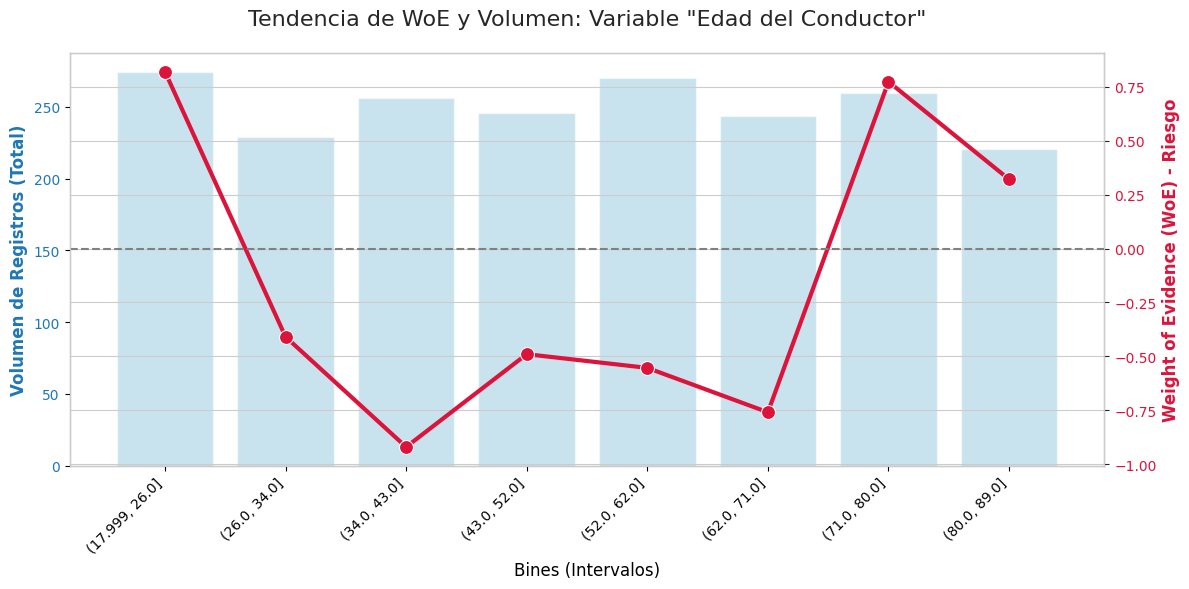

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. GENERACIÓN DE DATOS FALSOS (Simulando Riesgo en "U") ---
np.random.seed(42)
# Creamos 2000 conductores entre 18 y 90 años
df = pd.DataFrame({'edad': np.random.randint(18, 90, 2000)})
# Inicializamos target en 0 (Buenos) con un riesgo base del 10%
df['target'] = np.random.choice([0, 1], size=len(df), p=[0.9, 0.1])

# FORZAMOS LA "U": Aumentamos riesgo en extremos
# Jóvenes (<25): Riesgo del 40%
mask_jovenes = df['edad'] < 25
df.loc[mask_jovenes, 'target'] = np.random.choice([0, 1], size=mask_jovenes.sum(), p=[0.6, 0.4])
# Ancianos (>70): Riesgo del 30%
mask_ancianos = df['edad'] > 70
df.loc[mask_ancianos, 'target'] = np.random.choice([0, 1], size=mask_ancianos.sum(), p=[0.7, 0.3])

# --- 2. FUNCIÓN HELPER PARA CALCULAR TABLA WOE ---
def get_woe_summary(df, feature, target, bins=8):
    # Usamos qcut para bines de igual frecuencia
    df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop').astype(str)

    # Agregamos conteos
    grouped = df.groupby('bin')[target].agg(['count', 'sum'])
    grouped.rename(columns={'count': 'Total', 'sum': 'Malos'}, inplace=True)
    grouped['Buenos'] = grouped['Total'] - grouped['Malos']

    # Proporciones (+ un epsilon pequeño para evitar división por cero)
    epsilon = 0.0001
    dist_malos = (grouped['Malos'] + epsilon) / grouped['Malos'].sum()
    dist_buenos = (grouped['Buenos'] + epsilon) / grouped['Buenos'].sum()

    # Cálculo del WoE
    grouped['WoE'] = np.log(dist_malos / dist_buenos)

    # Limpiamos para la gráfica (ordenamos por el índice que son los intervalos)
    return grouped.reset_index().sort_values('bin')

# Calculamos la data para graficar
woe_data = get_woe_summary(df, 'edad', 'target')

# --- 3. FUNCIÓN DE GRAFICADO PROFESIONAL (DOBLE EJE) ---
def plot_woe_trend(woe_df, feature_name):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.set_style("whitegrid")

    # --- Eje Y Izquierdo: Barras de Volumen ---
    sns.barplot(data=woe_df, x='bin', y='Total', color='skyblue', alpha=0.5, ax=ax1)
    ax1.set_ylabel('Volumen de Registros (Total)', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xlabel('Bines (Intervalos)', fontsize=12)
    # Rotamos etiquetas del eje X para que se lean bien los intervalos
    plt.xticks(rotation=45, ha='right')

    # --- Eje Y Derecho: Línea de WoE ---
    ax2 = ax1.twinx() # Creamos el segundo eje compartiendo el mismo X

    # Graficamos la línea con marcadores
    sns.lineplot(data=woe_df, x='bin', y='WoE', color='crimson', marker='o', linewidth=3, markersize=10, ax=ax2, sort=False)

    # Agregamos una línea horizontal en WoE=0 (Punto neutral)
    ax2.axhline(0, color='grey', linestyle='--', linewidth=1.5)

    ax2.set_ylabel('Weight of Evidence (WoE) - Riesgo', color='crimson', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='crimson')

    # Títulos y ajuste
    plt.title(f'Tendencia de WoE y Volumen: Variable "{feature_name}"', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# --- 4. EJECUTAR LA GRÁFICA ---
plot_woe_trend(woe_data, 'Edad del Conductor')

In [35]:
import pandas as pd
import numpy as np

# 1. Definir los márgenes (edges) de forma explícita
# El primer valor es el límite inferior y el último el superior
margenes_edad = [0, 25, 35, 50, 65, 120]
etiquetas = ['Muy Joven', 'Joven', 'Adulto', 'Senior', 'Anciano']

# 2. Aplicar el binning marginalizado
df['edad_bin_manual'] = pd.cut(
    df['edad'],
    bins=margenes_edad,
    labels=etiquetas,
    include_lowest=True
)

# 3. ¿Por qué marginalizar?
# Porque ahora puedes guardar 'margenes_edad' en un archivo (JSON/PKL)
# y aplicarlo igualito a cualquier dato nuevo.

In [36]:
# Guardamos los márgenes en un diccionario para el Pipeline de Producción
config_limpieza = {
    'feature': 'edad',
    'bins': [0, 25, 35, 50, 65, 120],
    'woe_map': {
        'Muy Joven': 0.85,  # Riesgo alto
        'Joven': 0.10,
        'Adulto': -0.45,    # Riesgo bajo (negativo)
        'Senior': -0.20,
        'Anciano': 0.55     # Riesgo sube de nuevo
    }
}

# En producción, solo haces esto:
def transformar_edad(valor):
    # 1. Binning marginalizado
    categoria = pd.cut([valor], bins=config_limpieza['bins'], labels=etiquetas)[0]
    # 2. Sustitución por WoE
    return config_limpieza['woe_map'][categoria]

print(f"El valor de riesgo para una edad de 22 años es: {transformar_edad(22)}")

El valor de riesgo para una edad de 22 años es: 0.85


#  Mitos y Realidades del Preprocesamiento de Datos

Antes de entrenar tu modelo, es vital romper con ciertas creencias que pueden arruinar tu desempeño en producción. No todo lo que brilla es oro en la limpieza de datos.


### 1. "Normalizar datos los vuelve normales (Gaussianos)"
* **Mito:** El `StandardScaler` o `MinMaxScaler` cambian la forma de la distribución a una campana de Gauss.
* **Realidad:** **Falso.** Los escaladores solo cambian el **rango** (escala) y el **centro** de los datos. Si tus datos originales son sesgados, seguirán siendo sesgados. Para cambiar la forma de la distribución, necesitas **Box-Cox** o **Yeo-Johnson**.




### 2. "One-Hot Encoding es siempre superior a Label Encoding"
* **Mito:** Siempre hay que usar One-Hot para evitar "inventar" órdenes jerárquicos.
* **Realidad:** Depende del modelo y la cardinalidad.
    * En **Modelos de Árboles** (Random Forest, XGBoost), el Label Encoding funciona perfectamente.
    * El One-Hot en variables de **alta cardinalidad** (ej. 5,000 colonias) crea matrices gigantes que saturan la memoria y degradan el rendimiento.





### 3. "Puedo escalar todo mi dataset antes del Split"
* **Mito:** "Si escalo todo el CSV antes de dividirlo en Train y Test, mis datos estarán parejitos".
* **Realidad:** Esto se llama **Data Leakage** (Fuga de datos). Al escalar con todo el dataset, la media y desviación de tu conjunto de entrenamiento "saben" cosas sobre el futuro (conjunto de prueba). **El Fit se hace exclusivamente en Train.**





### 4. "Los Outliers son basura y deben borrarse"
* **Mito:** Si un dato se sale de la norma, estorba y hay que eliminar la fila.
* **Realidad:** Un outlier puede ser la señal más importante (ej. un fraude millonario o una falla crítica). Antes de borrar, usa **Capping (Winsorizing)** o transformaciones logarítmicas. **Si borras el outlier, borras la capacidad del modelo para detectarlo.**





### 5. "El orden del preprocesamiento no importa"
* **Mito:** Mientras limpie nulos, escale y codifique, el orden da igual.
* **Realidad:** El orden lo es **todo**.
    * Si escalas antes de imputar nulos, el `NaN` romperá el cálculo.
    * Si haces Box-Cox después de escalar a un rango negativo, la fórmula tronará (Box-Cox requiere $y > 0$).
